Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(134198, 64)
Unnamed: 0         134198
majority_target         2
statement            1058
BinaryNumTarget         2
tweet              134198
                    ...  
ampersand              12
capitals              238
digits                118
long_word_freq         48
short_word_freq        92
Length: 64, dtype: int64
Text Columns:
['statement', 'tweet', 'embeddings']

Continuous Numerical Columns:
['Unnamed: 0', 'followers_count', 'friends_count', 'favourites_count', 'statuses_count', 'listed_count', 'cred', 'normalize_influence', 'mentions', 'quotes', 'replies', 'retweets', 'favourites', 'hashtags', 'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage', 'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage', 'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage', 'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage', 'EV

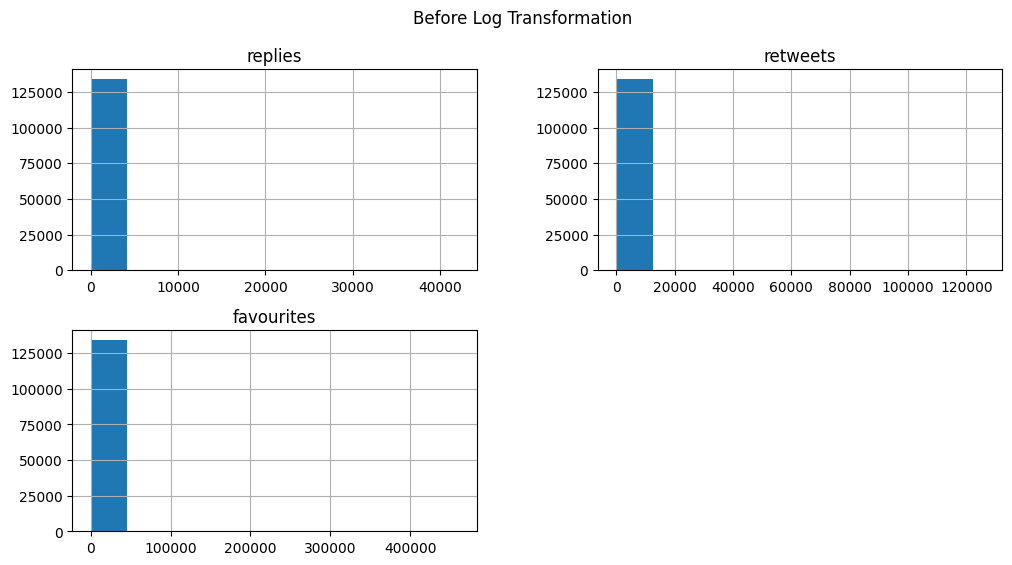

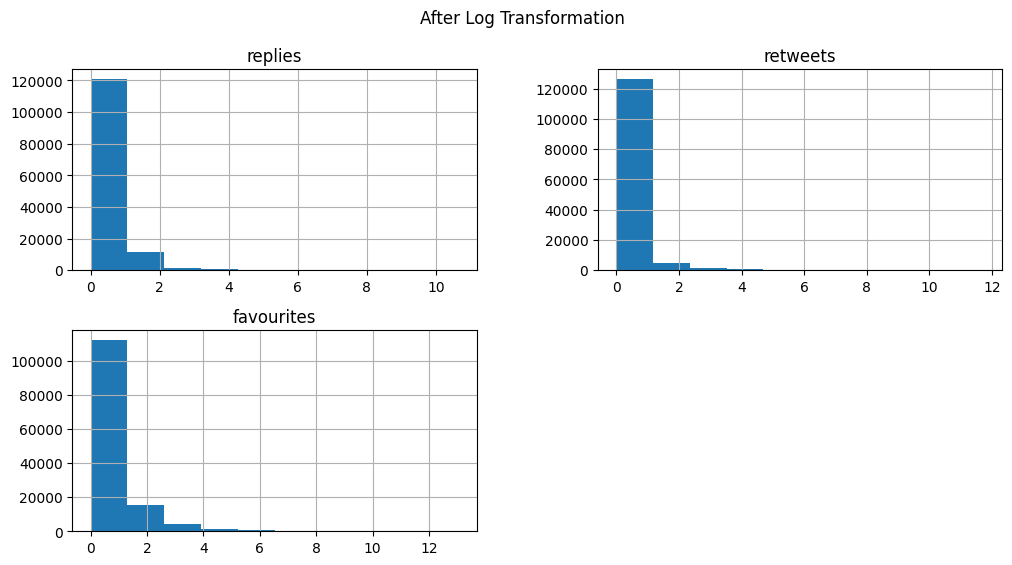

replies
Before: 308.86081334615363
After: 3.507922260502715

retweets
Before: 246.68367027629085
After: 5.041673816305872

favourites
Before: 218.9976040982767
After: 2.9792065047794707



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
from google.colab import drive

# ------------ Load data ----------------
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Features_For_Traditional_ML_Techniques (1).csv")

# ----------- Inspect data --------------
# Show number of rows and columns / value types
print(df.shape)
print(df.nunique())

# Text columns
text_columns = df.select_dtypes(include=['object']).columns
print("Text Columns:")
print(text_columns.tolist())

# Continuous numerical columns
continuous_columns = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if df[col].nunique() > 10
]
print("\nContinuous Numerical Columns:")
print(continuous_columns)

# Numerical columns with only a few unique values
few_value_columns = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if df[col].nunique() <= 10
]
print("\nNumbers With Few Distinct Values (Possibly Categorical):")
print(few_value_columns)

# ----------------- One hot encoding -------------
# Identify one categorical feature
categorical_columns = ['URLs']

# Apply one hot encoding
data_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Display the first few rows after encoding
print(data_encoded["URLs_1.0"])

# --------- Log Transformation/  Plot the distribution -----------
# top most skewed features
skewed_features = ['replies', 'retweets', 'favourites']

# Plot distributions before log transformation
df[skewed_features].hist(figsize=(12, 6))
plt.suptitle("Before Log Transformation")
plt.show()

# Create a copy of the data
df_log = df.copy()

# Apply log(x+1) transformation
for column in skewed_features:
    df_log[column] = np.log1p(df_log[column])

# Plot distributions after log transformation
df_log[skewed_features].hist(figsize=(12, 6))
plt.suptitle("After Log Transformation")
plt.show()

# --------- Calculate Skewness ----------
for feature in features:
    print(feature)
    print("Before:", stats.skew(df[feature], bias=False))
    print("After:", stats.skew(df_log[feature], bias=False))
    print()